In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import zipfile

# 1. Locate the directories dynamically
def get_dataset_paths(start_path='/content'):
    paths = {}
    for root, dirs, files in os.walk(start_path):
        if 'train' in dirs and 'test' in dirs:
            paths['train'] = os.path.join(root, 'train')
            paths['val'] = os.path.join(root, 'val')
            paths['test'] = os.path.join(root, 'test')
            break
    return paths

# Get paths
found_paths = get_dataset_paths()

if not found_paths:
    print("Dataset not found! Please upload/unzip the dataset first.")
else:
    TRAIN_DIR = found_paths['train']
    VAL_DIR = found_paths['val']
    TEST_DIR = found_paths['test']
    print(f"Paths Found Successfully:\nTrain: {TRAIN_DIR}\nVal: {VAL_DIR}\nTest: {TEST_DIR}")

# Constants
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
MODEL_SAVE_PATH = '/content/pneumonia_final_model.h5'

Paths Found Successfully:
Train: /content/drive/MyDrive/chest_xray/chest_xray/train
Val: /content/drive/MyDrive/chest_xray/chest_xray/val
Test: /content/drive/MyDrive/chest_xray/chest_xray/test


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import os

# --- PATHS FROM YOUR PREVIOUS OUTPUT ---
TRAIN_DIR = '/content/drive/MyDrive/chest_xray/chest_xray/train'
VAL_DIR = '/content/drive/MyDrive/chest_xray/chest_xray/val'
TEST_DIR = '/content/drive/MyDrive/chest_xray/chest_xray/test'
MODEL_SAVE_PATH = '/content/drive/MyDrive/pneumonia_detection_model.h5'

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# --- DATA AUGMENTATION ---
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary')

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary')

# --- MODEL BUILDING ---
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer=optimizers.Adam(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# --- SAVING OPTION ---
# This saves the best model to your Drive automatically
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    MODEL_SAVE_PATH, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)

print("Starting training...")
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=[checkpoint]
)

Found 5228 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Starting training...
Epoch 1/30
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8030 - loss: 0.4245
Epoch 1: val_accuracy improved from None to 0.75000, saving model to /content/drive/MyDrive/pneumonia_detection_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/pneumonia_detection_model.h5
164/164 ━━━━━━━━━━━━━━━━━━━━ 262s 1s/step - accuracy: 0.8640 - loss: 0.3118 - val_accuracy: 0.7500 - val_loss: 0.4259
Epoch 2/30
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 849ms/step - accuracy: 0.9239 - loss: 0.1949
Epoch 2: val_accuracy did not improve from 0.75000
164/164 ━━━━━━━━━━━━━━━━━━━━ 140s 851ms/step - accuracy: 0.9267 - loss: 0.1830 - val_accuracy: 0.7500 - val_loss: 0.4458
Epoch 3/30
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 831ms/step - accuracy: 0.9348 - loss: 0.1686
Epoch 3: val_accuracy did not improve from 0.75000
164/164 ━━━━━━━━━━━━━━━━━━━━ 137s 832ms/step - accuracy: 0.9332 - loss: 0.1672 - val_accuracy: 0.7500 - val_loss: 0.4844
Epoch 4/30
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 823ms/step - accuracy: 0.9403 - loss: 0.1405
Epoch 4: val_accuracy did not improve from 0.75000
164/164 ━━━━━━━━━━━━━━━━━━━━ 136s 827ms/step - accuracy: 0.9388 - loss: 0.1449 - val_accuracy: 0.7500 - val_loss: 0.4380
Epoch 5/30
164/


Epoch 5: finished saving model to /content/drive/MyDrive/pneumonia_detection_model.h5
164/164 ━━━━━━━━━━━━━━━━━━━━ 143s 869ms/step - accuracy: 0.9461 - loss: 0.1351 - val_accuracy: 0.8125 - val_loss: 0.4125
Epoch 6/30
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 844ms/step - accuracy: 0.9434 - loss: 0.1422
Epoch 6: val_accuracy did not improve from 0.81250
164/164 ━━━━━━━━━━━━━━━━━━━━ 139s 846ms/step - accuracy: 0.9468 - loss: 0.1318 - val_accuracy: 0.8125 - val_loss: 0.3324
Epoch 7/30
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 828ms/step - accuracy: 0.9574 - loss: 0.1142
Epoch 7: val_accuracy did not improve from 0.81250
164/164 ━━━━━━━━━━━━━━━━━━━━ 136s 830ms/step - accuracy: 0.9543 - loss: 0.1222 - val_accuracy: 0.8125 - val_loss: 0.4016
Epoch 8/30
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 852ms/step - accuracy: 0.9467 - loss: 0.1306
Epoch 8: val_accuracy improved from 0.81250 to 0.87500, saving model to /content/drive/MyDrive/pneumonia_detection_model.h5



Epoch 8: finished saving model to /content/drive/MyDrive/pneumonia_detection_model.h5
164/164 ━━━━━━━━━━━━━━━━━━━━ 143s 870ms/step - accuracy: 0.9516 - loss: 0.1225 - val_accuracy: 0.8750 - val_loss: 0.4086
Epoch 9/30
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 811ms/step - accuracy: 0.9559 - loss: 0.1187
Epoch 9: val_accuracy did not improve from 0.87500
164/164 ━━━━━━━━━━━━━━━━━━━━ 133s 812ms/step - accuracy: 0.9606 - loss: 0.1098 - val_accuracy: 0.8750 - val_loss: 0.3962
Epoch 10/30
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 797ms/step - accuracy: 0.9604 - loss: 0.1124
Epoch 10: val_accuracy did not improve from 0.87500
164/164 ━━━━━━━━━━━━━━━━━━━━ 131s 799ms/step - accuracy: 0.9593 - loss: 0.1106 - val_accuracy: 0.8125 - val_loss: 0.3966
Epoch 11/30
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 799ms/step - accuracy: 0.9544 - loss: 0.1134
Epoch 11: val_accuracy did not improve from 0.87500
164/164 ━━━━━━━━━━━━━━━━━━━━ 131s 801ms/step - accuracy: 0.9552 - loss: 0.1117 - val_accuracy: 0.8750 - val_loss: 0.3864
Epoch 12

In [ ]:
from tensorflow.keras.models import load_model

if os.path.exists(MODEL_SAVE_PATH):
    model = load_model(MODEL_SAVE_PATH)
    print("Model successfully retrieved from your Google Drive!")
else:
    print("Model file not found. Ensure your Drive is mounted.")

Model successfully retrieved from your Google Drive!


Found 624 images belonging to 2 classes.

Evaluating on Test Data...
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 343ms/step - accuracy: 0.9071 - loss: 0.2414
Test Loss: 0.2414
Test Accuracy: 0.9071
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 387ms/step

LOADED MODEL PERFORMANCE
              precision    recall  f1-score   support

      Normal       0.92      0.82      0.87       234
   Pneumonia       0.90      0.96      0.93       390

    accuracy                           0.91       624
   macro avg       0.91      0.89      0.90       624
weighted avg       0.91      0.91      0.91       624

Final F1-Score: 0.9279


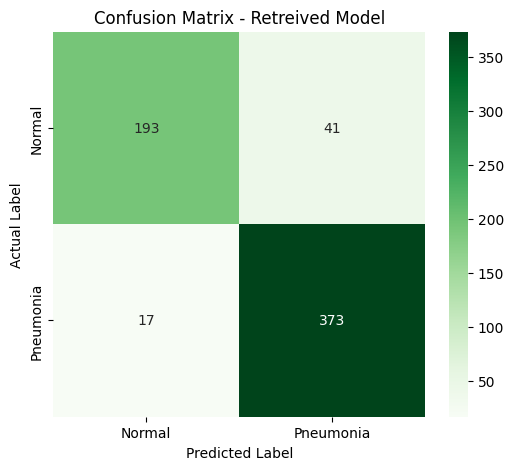

In [7]:
import numpy as np
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Re-initialize the test generator for the loaded model
# (Ensure val_test_datagen and TEST_DIR are still defined from previous cells)
test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

# 2. Run evaluation to "build" the metrics and see Loss/Accuracy
print("\nEvaluating on Test Data...")
loss, accuracy = model.evaluate(test_generator)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# 3. Get Predictions for F1 Score and Confusion Matrix
test_generator.reset()
preds = model.predict(test_generator)
y_pred = (preds > 0.5).astype(int).flatten()
y_true = test_generator.classes

# 4. Detailed Report
print("\n" + "="*30)
print("LOADED MODEL PERFORMANCE")
print("="*30)
print(classification_report(y_true, y_pred, target_names=['Normal', 'Pneumonia']))
print(f"Final F1-Score: {f1_score(y_true, y_pred):.4f}")

# 5. Visual Confusion Matrix (Optional but great for projects)
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Normal', 'Pneumonia'], yticklabels=['Normal', 'Pneumonia'])
plt.title('Confusion Matrix - Retreived Model')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

Saving NORMAL2-IM-1315-0001.jpeg to NORMAL2-IM-1315-0001 (1).jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
The model is 99.29% confident that this is NORMAL.


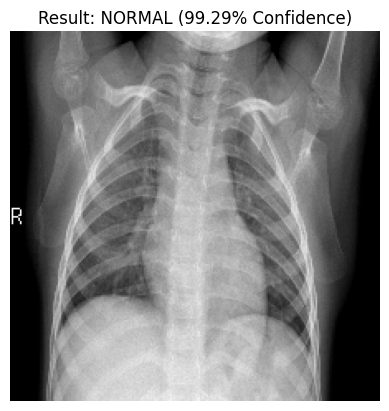

In [8]:
import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# 1. Upload the file
uploaded = files.upload()

for filename in uploaded.keys():
    # 2. Preprocess the image
    img_path = filename
    img = image.load_img(img_path, target_size=(224, 224))

    # Convert to array and normalize
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) # Add batch dimension
    img_array /= 255.0 # Rescale pixels to [0,1]

    # 3. Predict
    prediction = model.predict(img_array)

    # 4. Display Result
    plt.imshow(img)
    plt.axis('off')

    if prediction[0] > 0.5:
        confidence = prediction[0][0] * 100
        plt.title(f"Result: PNEUMONIA ({confidence:.2f}% Confidence)")
        print(f"The model is {confidence:.2f}% confident that this is PNEUMONIA.")
    else:
        confidence = (1 - prediction[0][0]) * 100
        plt.title(f"Result: NORMAL ({confidence:.2f}% Confidence)")
        print(f"The model is {confidence:.2f}% confident that this is NORMAL.")

    plt.show()
    .0